# Car Damage Classification
## Computer Vision Block

**Dataset:** Car Damage Severity Dataset (Kaggle – prajwalbhamere)

**Goal:** Classify a car photo into one of three damage categories and output a `condition_score` (0 = no damage, 1 = minor damage, 2 = major damage) that feeds into the ML price prediction block.

**Integration:** `Car photo → CV → condition_score → ML block (price prediction) → NLP block (explanation)`

## Project Setup
### Libraries and Settings

In [5]:
!pip install -q transformers accelerate evaluate datasets pillow scikit-learn torchvision

In [6]:
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm

from datasets import load_dataset, DatasetDict
from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
    Trainer,
    TrainingArguments,
    pipeline
)
import evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

print('GPU available:', torch.cuda.is_available())

GPU available: True


## 1. Data Loading and Inspection

**Data source:** [Car Damage Severity Dataset](https://www.kaggle.com/datasets/prajwalbhamere/car-damage-severity-dataset)

Attach to your Kaggle notebook via **'+ Add Input'**. The dataset must be organised in subfolders per class (ImageFolder format).

In [7]:
# Explore the folder structure first
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')
        for f in files[:2]:
            print('  ' * (level + 1) + f)

input/
  datasets/
    prajwalbhamere/


In [8]:
# Load dataset using imagefolder — automatically assigns labels from subfolder names
DATA_ROOT = '/kaggle/input/datasets/prajwalbhamere/car-damage-severity-dataset'

dataset = load_dataset('imagefolder', data_dir=DATA_ROOT)
dataset

Resolving data files:   0%|          | 0/1383 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/248 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1383
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 248
    })
})

In [9]:
# Inspect class names assigned by imagefolder
class_names = dataset['train'].features['label'].names
print('Class names from folders:', class_names)
print('Number of classes:', len(class_names))

# Map to our condition_score (0=no damage, 1=minor, 2=major)
# Adjust this mapping if the folder names differ from what is shown above
label2id = {name: i for i, name in enumerate(class_names)}
id2label  = {i: name for i, name in enumerate(class_names)}

NUM_LABELS = len(class_names)
print('label2id:', label2id)

Class names from folders: ['01-minor', '02-moderate', '03-severe']
Number of classes: 3
label2id: {'01-minor': 0, '02-moderate': 1, '03-severe': 2}


In [10]:
# Split: 70% train / 15% val / 15% test
split = dataset['train'].train_test_split(test_size=0.3, seed=42)
val_test = split['test'].train_test_split(test_size=0.5, seed=42)

our_dataset = DatasetDict({
    'train':      split['train'],
    'validation': val_test['train'],
    'test':       val_test['test']
})
our_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 968
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 207
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 208
    })
})

## 2. Exploratory Data Analysis (EDA)

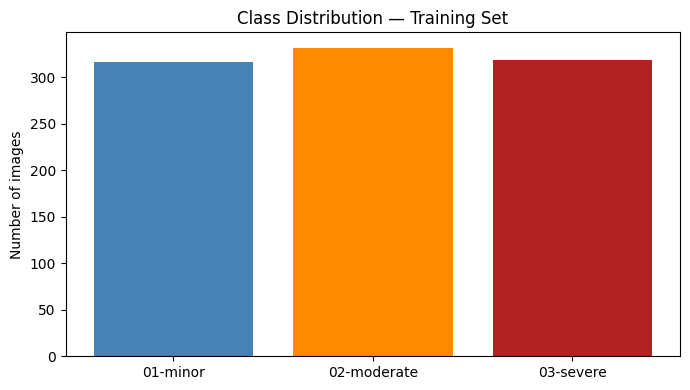

In [11]:
# Class distribution
labels_all = our_dataset['train']['label']
counts = [labels_all.count(i) for i in range(NUM_LABELS)]
plt.figure(figsize=(7, 4))
plt.bar(class_names, counts, color=['steelblue', 'darkorange', 'firebrick'])
plt.title('Class Distribution — Training Set')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

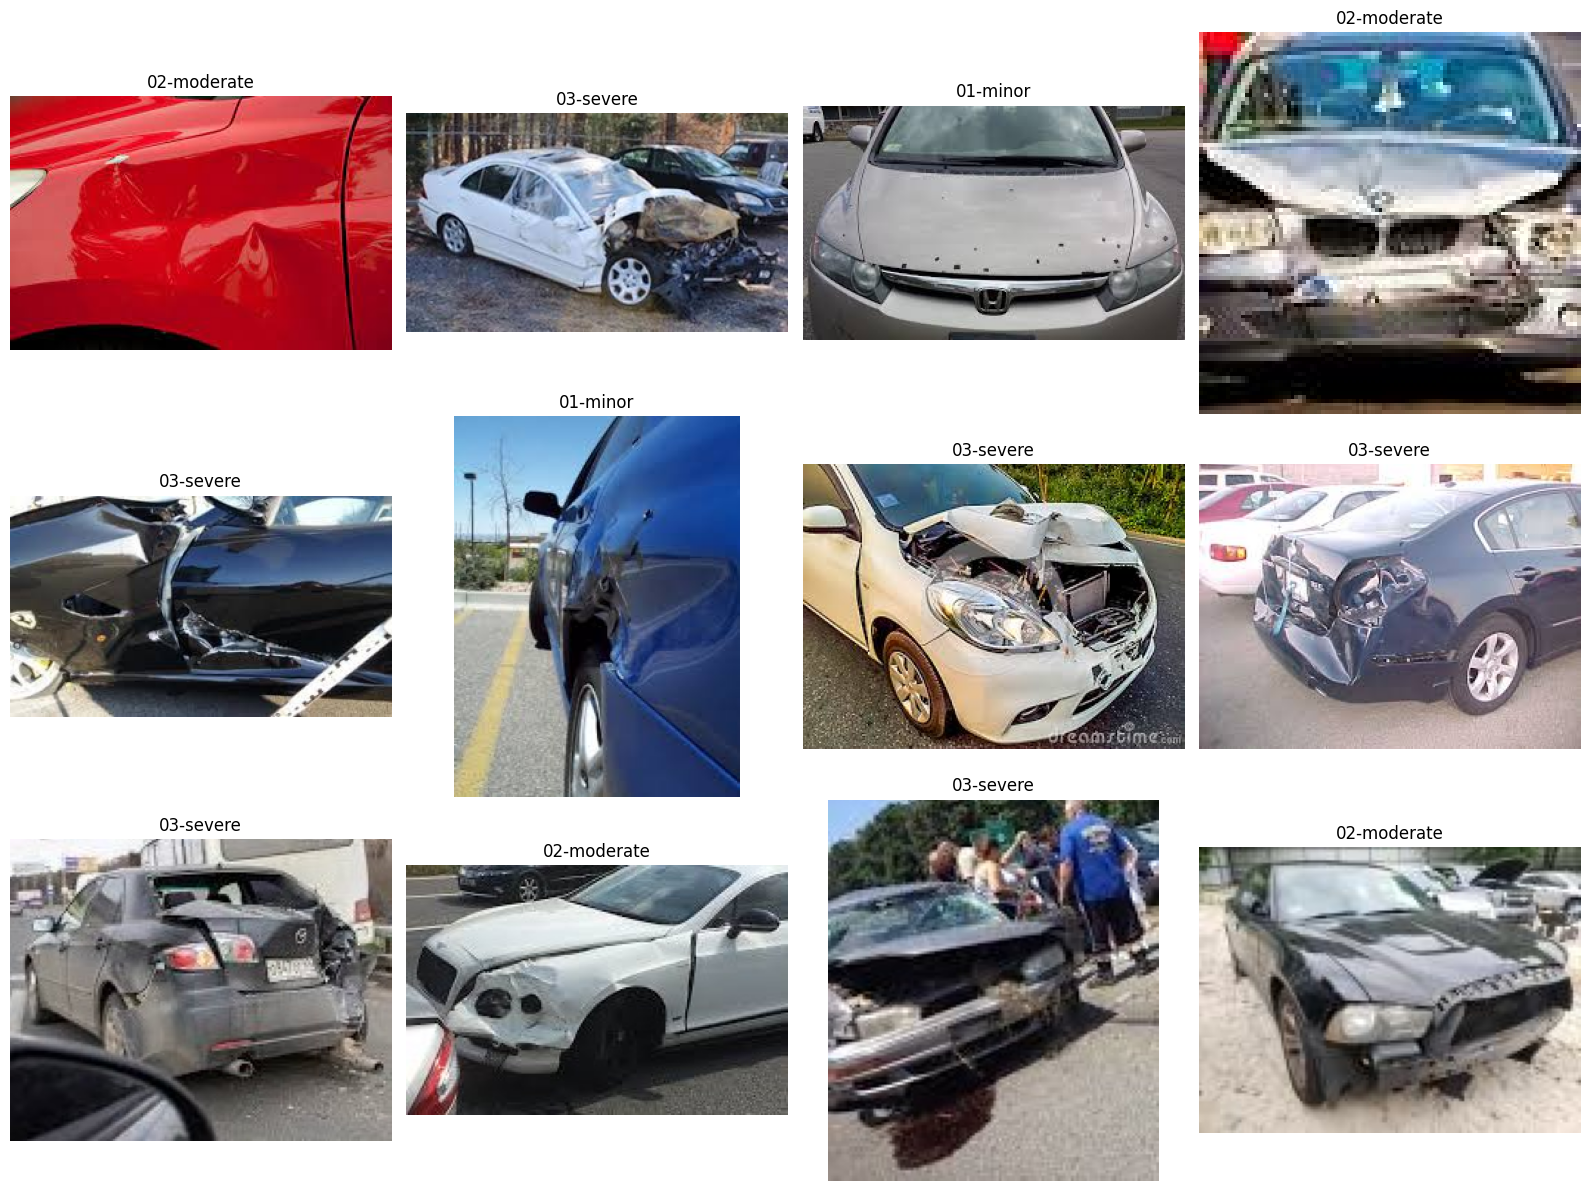

In [12]:
# Sample images per class
def show_samples(ds, rows, cols):
    samples = ds.shuffle(seed=42).select(np.arange(rows * cols))
    fig = plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(rows * cols):
        img = samples[i]['image']
        if not hasattr(img, 'convert'):
            img = Image.open(io.BytesIO(img['bytes']))
        label = id2label[samples[i]['label']]
        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(our_dataset['train'], rows=3, cols=4)

## 3. Preprocessing

Using `AutoImageProcessor` from `google/vit-base-patch16-224` — resizes to 224×224 and normalises pixel values to mean/std 0.5, as required by ViT.

In [13]:
processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')
processor

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [14]:
# Standard transform (no augmentation) — used for val/test and Iteration 2 training
def transforms(batch):
    images = [img.convert('RGB') if hasattr(img, 'convert')
              else Image.open(io.BytesIO(img['bytes'])).convert('RGB')
              for img in batch['image']]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

# Augmented transform — used for Iteration 3 training only
from torchvision import transforms as T

augmentation = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomRotation(10),
])

def transforms_augmented(batch):
    images = [img.convert('RGB') if hasattr(img, 'convert')
              else Image.open(io.BytesIO(img['bytes'])).convert('RGB')
              for img in batch['image']]
    images = [augmentation(img) for img in images]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

accuracy_metric = evaluate.load('accuracy')
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

---
## Iteration 1 — Zero-Shot Baseline with CLIP

**Objective:** Establish a zero-shot baseline using CLIP. No training required — CLIP matches image embeddings to text descriptions of each damage class.

**Model:** `openai/clip-vit-large-patch14` (same checkpoint as Week 7 exercise)

**Why:** Measures how well a general vision-language model understands car damage concepts without any task-specific supervision.

In [15]:
# Zero-shot CLIP — same pipeline approach as Week 7
clip_detector = pipeline(
    model='openai/clip-vit-large-patch14',
    task='zero-shot-image-classification'
)

# Text descriptions for each class (maps to condition_score 0 / 1 / 2)
candidate_labels = [
    'a car with no damage',
    'a car with minor damage or small dents',
    'a car with major damage or severe collision'
]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [16]:
# Evaluate CLIP on the test set
test_sample = our_dataset['test'].shuffle(seed=42).select(range(min(150, len(our_dataset['test']))))

true_labels_clip = []
pred_labels_clip = []

for sample in tqdm(test_sample):
    img = sample['image']
    if not hasattr(img, 'convert'):
        img = Image.open(io.BytesIO(img['bytes']))
    results = clip_detector(img, candidate_labels=candidate_labels)
    pred_idx = candidate_labels.index(max(results, key=lambda x: x['score'])['label'])
    true_labels_clip.append(sample['label'])
    pred_labels_clip.append(pred_idx)

clip_acc = accuracy_score(true_labels_clip, pred_labels_clip)
print(f'CLIP Zero-Shot Accuracy: {clip_acc:.4f}')
print()
print(classification_report(true_labels_clip, pred_labels_clip, target_names=class_names))

100%|██████████| 150/150 [00:12<00:00, 12.37it/s]

CLIP Zero-Shot Accuracy: 0.2933

              precision    recall  f1-score   support

    01-minor       0.18      0.14      0.16        50
 02-moderate       0.29      0.67      0.40        45
   03-severe       0.88      0.13      0.22        55

    accuracy                           0.29       150
   macro avg       0.45      0.31      0.26       150
weighted avg       0.47      0.29      0.26       150



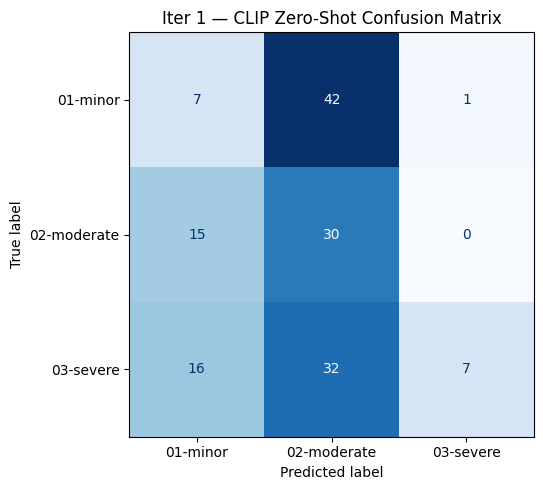

In [17]:
# Confusion matrix — CLIP
cm = confusion_matrix(true_labels_clip, pred_labels_clip)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Iter 1 — CLIP Zero-Shot Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Iteration 2 — Transfer Learning: ViT with Frozen Backbone

**Objective:** Fine-tune only the classification head of ViT on the damage dataset. All pretrained backbone weights are frozen.

**Model:** `google/vit-base-patch16-224` — same as Week 6 exercise.

**Key changes vs Iteration 1:** Task-specific supervised training; only 28k parameters trained (classifier head).

In [18]:
# Apply standard transforms (no augmentation)
processed_dataset = our_dataset.with_transform(transforms)

In [19]:
# Load ViT — replace classifier head for NUM_LABELS classes
vit_iter2 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Freeze all layers except the classifier head
for name, p in vit_iter2.named_parameters():
    if not name.startswith('classifier'):
        p.requires_grad = False

num_params       = sum(p.numel() for p in vit_iter2.parameters())
trainable_params = sum(p.numel() for p in vit_iter2.parameters() if p.requires_grad)
print(f'{num_params = :,} | {trainable_params = :,}')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


num_params = 85,800,963 | trainable_params = 2,307


In [20]:
training_args_iter2 = TrainingArguments(
    output_dir='./vit-damage-iter2',
    per_device_train_batch_size=16,
    num_train_epochs=5,
    learning_rate=3e-4,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    remove_unused_columns=False,
    logging_steps=50,
    report_to='none',
    disable_tqdm=True
)

trainer_iter2 = Trainer(
    model=vit_iter2,
    args=training_args_iter2,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_dataset['train'],
    eval_dataset=processed_dataset['validation'],
    processing_class=processor
)

trainer_iter2.train()

{'eval_loss': '0.9525', 'eval_accuracy': '0.5072', 'eval_runtime': '2.827', 'eval_samples_per_second': '73.22', 'eval_steps_per_second': '4.598', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.9943', 'grad_norm': '3.072', 'learning_rate': '0.0002052', 'epoch': '1.613'}
{'eval_loss': '0.8705', 'eval_accuracy': '0.5749', 'eval_runtime': '2.161', 'eval_samples_per_second': '95.8', 'eval_steps_per_second': '6.017', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.8352', 'eval_accuracy': '0.5894', 'eval_runtime': '2.183', 'eval_samples_per_second': '94.84', 'eval_steps_per_second': '5.956', 'epoch': '3'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.7817', 'grad_norm': '2.465', 'learning_rate': '1.161e-05', 'epoch': '4.839'}
{'eval_loss': '0.8179', 'eval_accuracy': '0.6087', 'eval_runtime': '2.187', 'eval_samples_per_second': '94.67', 'eval_steps_per_second': '5.945', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '73.41', 'train_samples_per_second': '65.93', 'train_steps_per_second': '2.111', 'train_loss': '0.8631', 'epoch': '5'}


TrainOutput(global_step=155, training_loss=0.8631069521750173, metrics={'train_runtime': 73.4127, 'train_samples_per_second': 65.929, 'train_steps_per_second': 2.111, 'train_loss': 0.8631069521750173, 'epoch': 5.0})

In [21]:
results_iter2 = trainer_iter2.evaluate(processed_dataset['test'])
print('Iteration 2 Test Results:', results_iter2)

preds_iter2  = trainer_iter2.predict(processed_dataset['test'])
y_pred_iter2 = preds_iter2.predictions.argmax(axis=1)
y_true       = preds_iter2.label_ids

print()
print(classification_report(y_true, y_pred_iter2, target_names=class_names))

{'eval_loss': '0.7906', 'eval_accuracy': '0.6202', 'eval_runtime': '2.379', 'eval_samples_per_second': '87.42', 'eval_steps_per_second': '5.464', 'epoch': '5'}
Iteration 2 Test Results: {'eval_loss': 0.7905606031417847, 'eval_accuracy': 0.6201923076923077, 'eval_runtime': 2.3794, 'eval_samples_per_second': 87.416, 'eval_steps_per_second': 5.464, 'epoch': 5.0}

              precision    recall  f1-score   support

    01-minor       0.72      0.63      0.67        68
 02-moderate       0.47      0.55      0.51        66
   03-severe       0.69      0.68      0.68        74

    accuracy                           0.62       208
   macro avg       0.63      0.62      0.62       208
weighted avg       0.63      0.62      0.62       208



---
## Iteration 3 — Transfer Learning: ViT with Partial Unfreeze + Augmentation

**Objective:** Unfreeze the last 2 transformer encoder blocks in addition to the classifier head, and add image augmentation. Allows the backbone to adapt to car-specific damage features.

**Key changes vs Iteration 2:** Encoder layers 10 and 11 unfrozen (7.1M additional trainable params); random flip, colour jitter, and rotation augmentation added.

In [22]:
# Apply augmented transforms to training split only
processed_train_aug = our_dataset['train'].with_transform(transforms_augmented)
processed_val_test  = our_dataset.with_transform(transforms)  # no aug for val/test

In [23]:
vit_iter3 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Freeze entire backbone first, then selectively unfreeze
for name, p in vit_iter3.named_parameters():
    p.requires_grad = False

for name, p in vit_iter3.named_parameters():
    if ('encoder.layer.10' in name or
        'encoder.layer.11' in name or
        name.startswith('classifier')):
        p.requires_grad = True

num_params       = sum(p.numel() for p in vit_iter3.parameters())
trainable_params = sum(p.numel() for p in vit_iter3.parameters() if p.requires_grad)
print(f'{num_params = :,} | {trainable_params = :,}')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


num_params = 85,800,963 | trainable_params = 14,178,051


In [24]:
training_args_iter3 = TrainingArguments(
    output_dir='./vit-damage-iter3',
    per_device_train_batch_size=16,
    num_train_epochs=8,
    learning_rate=1e-4,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    remove_unused_columns=False,
    logging_steps=50,
    report_to='none',
    disable_tqdm=True
)

trainer_iter3 = Trainer(
    model=vit_iter3,
    args=training_args_iter3,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=processed_train_aug,
    eval_dataset=processed_val_test['validation'],
    processing_class=processor
)

trainer_iter3.train()

{'eval_loss': '0.7575', 'eval_accuracy': '0.6232', 'eval_runtime': '2.2', 'eval_samples_per_second': '94.09', 'eval_steps_per_second': '5.909', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.8693', 'grad_norm': '3.077', 'learning_rate': '8.024e-05', 'epoch': '1.613'}
{'eval_loss': '0.6672', 'eval_accuracy': '0.6329', 'eval_runtime': '2.253', 'eval_samples_per_second': '91.86', 'eval_steps_per_second': '5.769', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.6354', 'eval_accuracy': '0.6908', 'eval_runtime': '2.291', 'eval_samples_per_second': '90.34', 'eval_steps_per_second': '5.674', 'epoch': '3'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.6579', 'eval_accuracy': '0.7198', 'eval_runtime': '2.508', 'eval_samples_per_second': '82.53', 'eval_steps_per_second': '5.183', 'epoch': '8'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '144.4', 'train_samples_per_second': '53.63', 'train_steps_per_second': '1.718', 'train_loss': '0.5197', 'epoch': '8'}


TrainOutput(global_step=248, training_loss=0.5197264225252213, metrics={'train_runtime': 144.3832, 'train_samples_per_second': 53.635, 'train_steps_per_second': 1.718, 'train_loss': 0.5197264225252213, 'epoch': 8.0})

In [25]:
results_iter3 = trainer_iter3.evaluate(processed_val_test['test'])
print('Iteration 3 Test Results:', results_iter3)

preds_iter3  = trainer_iter3.predict(processed_val_test['test'])
y_pred_iter3 = preds_iter3.predictions.argmax(axis=1)

print()
print(classification_report(y_true, y_pred_iter3, target_names=class_names))

{'eval_loss': '0.7648', 'eval_accuracy': '0.6202', 'eval_runtime': '2.286', 'eval_samples_per_second': '91', 'eval_steps_per_second': '5.687', 'epoch': '8'}
Iteration 3 Test Results: {'eval_loss': 0.7647819519042969, 'eval_accuracy': 0.6201923076923077, 'eval_runtime': 2.2858, 'eval_samples_per_second': 90.998, 'eval_steps_per_second': 5.687, 'epoch': 8.0}

              precision    recall  f1-score   support

    01-minor       0.69      0.66      0.68        68
 02-moderate       0.44      0.52      0.48        66
   03-severe       0.76      0.68      0.71        74

    accuracy                           0.62       208
   macro avg       0.63      0.62      0.62       208
weighted avg       0.64      0.62      0.63       208



In [26]:
# --- Model Comparison Summary ---
print('=== Model Comparison ===')
print(f'Iter 1 – CLIP zero-shot accuracy:              {clip_acc:.4f}')
print(f'Iter 2 – ViT frozen backbone accuracy:         {results_iter2["eval_accuracy"]:.4f}')
print(f'Iter 3 – ViT partial unfreeze + aug accuracy:  {results_iter3["eval_accuracy"]:.4f}')

=== Model Comparison ===
Iter 1 – CLIP zero-shot accuracy:              0.2933
Iter 2 – ViT frozen backbone accuracy:         0.6202
Iter 3 – ViT partial unfreeze + aug accuracy:  0.6202


## 4. Error Analysis

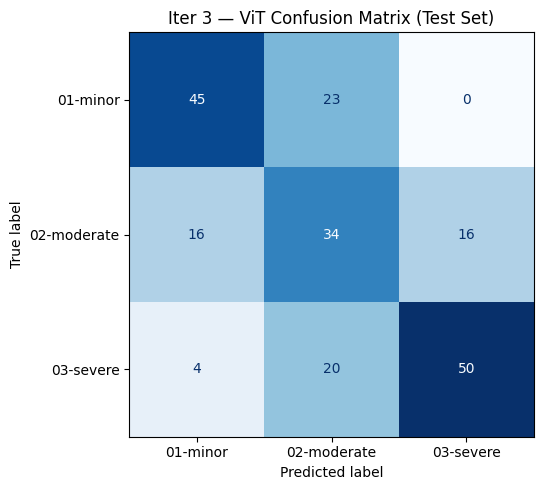

In [27]:
# Confusion matrix — best model (Iter 3)
cm = confusion_matrix(y_true, y_pred_iter3)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Iter 3 — ViT Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

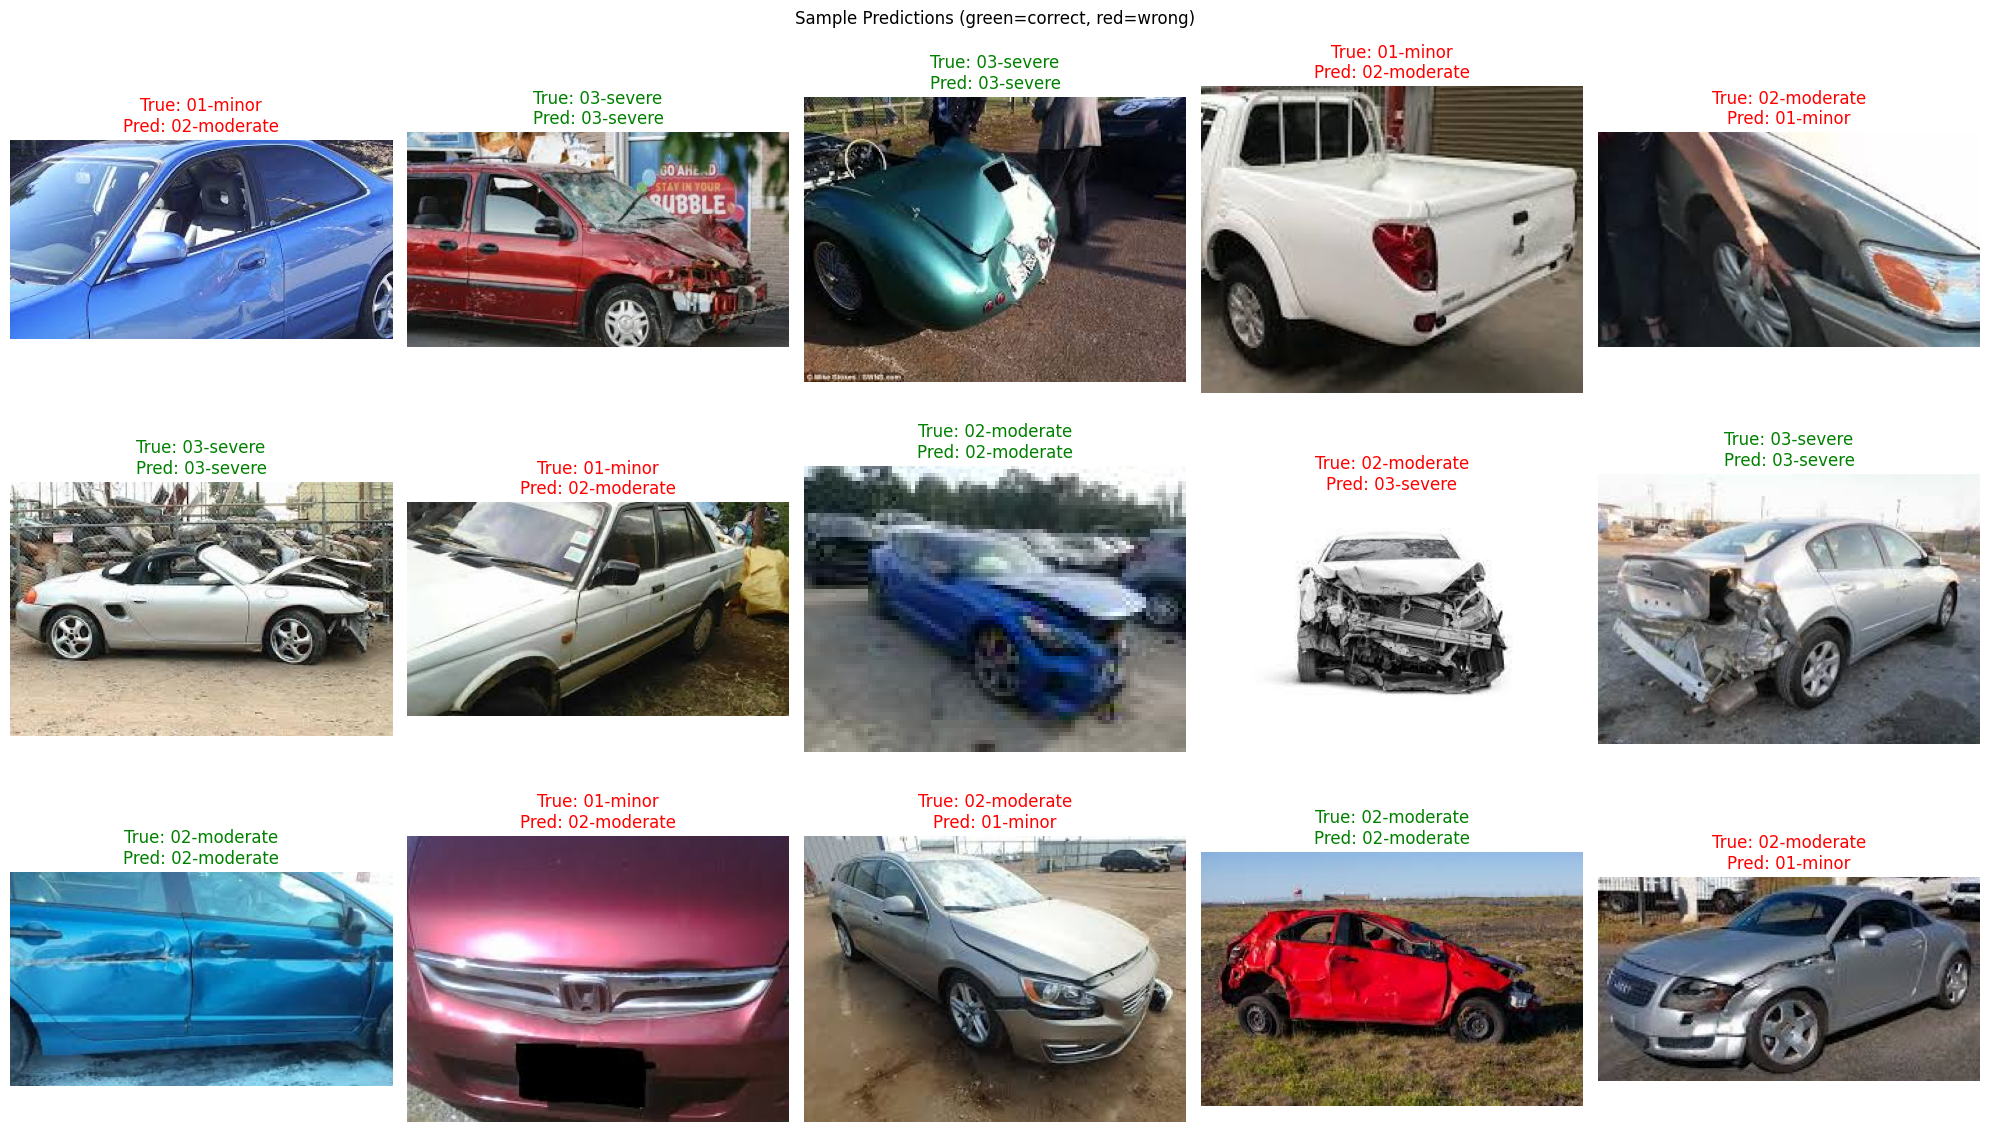

In [28]:
# Visual inspection of predictions
def show_predictions(rows, cols):
    samples = our_dataset['test'].shuffle(seed=99).select(np.arange(rows * cols))
    processed_samples = samples.with_transform(transforms)
    predictions = trainer_iter3.predict(processed_samples).predictions.argmax(axis=1)
    fig = plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(rows * cols):
        img = samples[i]['image']
        if not hasattr(img, 'convert'):
            img = Image.open(io.BytesIO(img['bytes']))
        true_l = id2label[samples[i]['label']]
        pred_l = id2label[predictions[i]]
        colour = 'green' if true_l == pred_l else 'red'
        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f'True: {true_l}\nPred: {pred_l}', color=colour)
        plt.axis('off')
    plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=12)
    plt.tight_layout()
    plt.show()

show_predictions(rows=3, cols=5)

## 5. Save Final Model

In [29]:
# Save model and processor (HuggingFace format)
vit_iter3.save_pretrained('./car_damage_model')
processor.save_pretrained('./car_damage_model')
print('Model saved to ./car_damage_model/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./car_damage_model/


## 6. Integration Test — Predict condition_score from a Single Image

Demonstrates how the ML block calls this function at inference time.

In [30]:
# Use pipeline for inference — same approach as Week 7 Gradio app
damage_classifier = pipeline(
    task='image-classification',
    model=vit_iter3,
    image_processor=processor
)

def predict_condition_score(image):
    """
    Returns condition_score: 0 = no damage, 1 = minor damage, 2 = major damage
    Input: PIL Image or file path
    """
    if isinstance(image, str):
        image = Image.open(image).convert('RGB')
    result = damage_classifier(image)
    top = max(result, key=lambda x: x['score'])
    condition_score = label2id[top['label']]
    print(f'condition_score: {condition_score}  ({top["label"]}, confidence: {top["score"]:.2%})')
    return condition_score

# Test on one image from the test set
sample = our_dataset['test'][0]
img = sample['image']
if not hasattr(img, 'convert'):
    img = Image.open(io.BytesIO(img['bytes']))

score = predict_condition_score(img)
print(f'True label: {id2label[sample["label"]]}')

condition_score: 0  (01-minor, confidence: 91.16%)
True label: 01-minor
